<a href="https://colab.research.google.com/github/Dark-Knight17/keystroke-dynamics-thesis/blob/main/keystroke_gru_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Keystroke Dynamics — GRU Autoencoder (One-Class Anomaly Detection)
### Sliding Window Protocol | One-Class LOO | Isolation Forest Baseline

**Architecture approach:**
- Sessions are sliced into overlapping windows of 50 real keystroke events
- Each window is 100% real data — no padding involved
- Autoencoder trained on genuine windows only; anomaly = high reconstruction error
- Session-level score = mean window MSE aggregated across all windows in a session

**Why sliding windows over full sessions:**
- Full 300-timestep approach: 9 training samples → model collapses to mean prediction
- Sliding windows: 9 sessions × ~6 windows = ~54 training samples → meaningful memorisation
- No padding in any window → no trivial zero-reconstruction artefacts

**Isolation Forest baseline:**
- Trained on genuine L2 feature vectors (from features.csv)
- Appropriate for N=12 genuine samples; compared against GRU-AE in final cell


In [3]:
from google.colab import drive
drive.mount('/content/drive')
!pip install scikit-learn -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('All imports successful.')

TensorFlow version: 2.20.0
GPU: []
All imports successful.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 1: LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH     = '/content/drive/MyDrive/Keystroke_data/events_with_abs_timestamps_26P_20_may_keepingg.csv'
FEATURES_PATH = '/content/drive/MyDrive/Keystroke_data/features_26P_20_may_keepingg.csv'

df = pd.read_csv(DATA_PATH)
df = df.sort_values(by=['session_id', 'event_sequence']).reset_index(drop=True)

encoder = LabelEncoder()
df['physical_code_encoded'] = encoder.fit_transform(df['physical_code'].astype(str))

print(f'Events loaded    : {len(df):,}')
print(f'Sessions         : {df["session_id"].nunique()}')
print(f'Participants     : {df["participant_id"].nunique()}')

Events loaded    : 175,339
Sessions         : 418
Participants     : 51


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 2: BUILD SESSIONS AND FILTER TO COMPLETE USERS
#
# Unlike the binary classifiers, we store sessions as VARIABLE-LENGTH arrays
# of real keystroke events only — no padding at this stage.
# The sliding window extractor (Part 3) will slice fixed-length windows from
# these real-data arrays, so padding is never needed.
# ─────────────────────────────────────────────────────────────────────────────

NUM_FEATURES = 3   # [physical_code_encoded, flight_time, text_length]
MIN_EVENTS   = 10  # minimum keydown events to keep a session

session_data   = []   # list of variable-length (T_real, 3) arrays
session_labels = []

for session_id, grp in df.groupby('session_id'):
    kd = grp[grp['event_type'] == 'keydown'].copy()
    if len(kd) < MIN_EVENTS:
        continue

    f_code   = kd['physical_code_encoded'].values.astype('float32')
    f_flight = kd['timestamp'].diff().fillna(0).clip(0, 2000).values.astype('float32')
    f_text   = kd['text_length'].values.astype('float32')

    seq = np.stack([f_code, f_flight, f_text], axis=1)  # (T_real, 3)
    session_data.append(seq)
    session_labels.append(grp['participant_id'].iloc[0])

labels       = np.array(session_labels)
unique_users = np.unique(labels)

# ── Filter to complete users only (>= 12 sessions in DB) ─────────────────
db_session_count  = df.groupby('participant_id')['session_id'].nunique()
complete_user_ids = db_session_count[db_session_count >= 12].index
keep         = np.isin(labels, complete_user_ids)
session_data = [session_data[i] for i in range(len(session_data)) if keep[i]]
labels       = labels[keep]
unique_users = np.unique(labels)

real_lengths = np.array([len(s) for s in session_data])
print(f'Complete users          : {len(unique_users)}')
print(f'Total sessions          : {len(session_data)}')
print(f'Real keystroke events   : min={real_lengths.min()}, '
      f'mean={real_lengths.mean():.0f}, max={real_lengths.max()}')

Complete users          : 26
Total sessions          : 314
Real keystroke events   : min=79, mean=206, max=508


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 3: FEATURE NORMALISATION
#
# Normalise across ALL real events in ALL sessions.
# Applied before window extraction so all windows share the same scale.
# ─────────────────────────────────────────────────────────────────────────────

all_events = np.vstack(session_data)   # (total_events, 3)
stats = {}

for f, name in enumerate(['physical_code', 'flight_time', 'text_length']):
    mu    = all_events[:, f].mean()
    sigma = all_events[:, f].std() + 1e-8
    stats[name] = (mu, sigma)

# Normalise each session in place
sessions_norm = []
for seq in session_data:
    seq_norm = seq.copy()
    for f, (mu, sigma) in enumerate(stats.values()):
        seq_norm[:, f] = (seq[:, f] - mu) / sigma
    sessions_norm.append(seq_norm)

print('Feature normalisation complete.')
for name, (mu, sigma) in stats.items():
    print(f'  {name:<20} mean: {mu:.2f},  std: {sigma:.2f}')

Feature normalisation complete.
  physical_code        mean: 47.00,  std: 22.05
  flight_time          mean: 445.15,  std: 488.03
  text_length          mean: 131.78,  std: 78.55


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 4: SLIDING WINDOW EXTRACTOR
#
# Converts each variable-length session into a set of fixed-length windows.
# Every window contains only real keystroke events — no padding ever included.
#
# WINDOW_SIZE = 50 : 50 consecutive keydown events per window
# STRIDE      = 25 : 50% overlap between adjacent windows
#
# A session with 180 real events produces:
#   (180 - 50) // 25 + 1 = 6 windows
#
# Session-level anomaly score = mean reconstruction error across all windows.
# ─────────────────────────────────────────────────────────────────────────────

WINDOW_SIZE = 50
STRIDE      = 25


def extract_windows(seq):
    """
    Extract sliding windows from a single session.
    seq : (T_real, F)  — normalised real keystroke events only
    Returns (n_windows, WINDOW_SIZE, F) or None if session too short.
    """
    T = len(seq)
    if T < WINDOW_SIZE:
        return None
    windows = []
    for start in range(0, T - WINDOW_SIZE + 1, STRIDE):
        windows.append(seq[start:start + WINDOW_SIZE])
    return np.array(windows, dtype='float32')   # (n_windows, 50, 3)


# Verify on a sample session
sample_windows = extract_windows(sessions_norm[0])
print(f'Sample session length : {len(sessions_norm[0])} real events')
print(f'Windows extracted     : {len(sample_windows)}')
print(f'Window shape          : {sample_windows.shape}')

# Report average windows per session across the full dataset
window_counts = []
for seq in sessions_norm:
    w = extract_windows(seq)
    if w is not None:
        window_counts.append(len(w))
print(f'\nWindows per session   : min={min(window_counts)}, '
      f'mean={np.mean(window_counts):.1f}, max={max(window_counts)}')
print(f'Expected genuine train windows (9 sessions): ~{int(9 * np.mean(window_counts))}')

Sample session length : 111 real events
Windows extracted     : 3
Window shape          : (3, 50, 3)

Windows per session   : min=2, mean=6.8, max=19
Expected genuine train windows (9 sessions): ~60


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 5: GRU AUTOENCODER ARCHITECTURE (Window-Based)
#
# Input shape: (WINDOW_SIZE, NUM_FEATURES) = (50, 3)
# Much smaller than the original (300, 3) — no padding required.
#
# Encoder: GRU(64) -> GRU(32)  [bottleneck: 32-dim typing signature]
# Decoder: RepeatVector(50) -> GRU(32) -> GRU(64) -> TimeDistributed(Dense(3))
#
# No Masking layer — all 50 timesteps in every window are real data.
# ─────────────────────────────────────────────────────────────────────────────

def build_gru_autoencoder(window_size=WINDOW_SIZE, num_features=NUM_FEATURES,
                           latent_dim=32, dropout=0.2):
    inputs = layers.Input(shape=(window_size, num_features), name='window_input')

    # ── Encoder ───────────────────────────────────────────────────────────
    x          = layers.GRU(64, return_sequences=True, name='enc_gru_1')(inputs)
    x          = layers.Dropout(dropout, name='enc_drop')(x)
    bottleneck = layers.GRU(latent_dim, return_sequences=False,
                            name='bottleneck')(x)

    # ── Decoder ───────────────────────────────────────────────────────────
    x       = layers.RepeatVector(window_size, name='repeat')(bottleneck)
    x       = layers.GRU(latent_dim, return_sequences=True,
                         name='dec_gru_1')(x)
    x       = layers.Dropout(dropout, name='dec_drop')(x)
    x       = layers.GRU(64, return_sequences=True, name='dec_gru_2')(x)
    outputs = layers.TimeDistributed(
        layers.Dense(num_features), name='reconstruction'
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name='GRU_AE_Window')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )
    return model


demo = build_gru_autoencoder()
demo.summary()
print(f'\nTotal parameters: {demo.count_params():,}')

Model: "GRU_AE_Window"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ window_input (InputLayer)       │ (None, 50, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_gru_1 (GRU)                 │ (None, 50, 64)         │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop (Dropout)              │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (GRU)                │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_gru_1 (GRU)                 │ (None, 50, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop (Dropout)              │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_gru_2 (GRU)                 │ (None, 50, 64)         │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 50, 3)          │           195 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,003 (187.51 KB)

 Trainable params: 48,003 (187.51 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 48,003


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 6: EVALUATION HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def compute_eer(y_true, y_scores):
    """Equal Error Rate — standard biometric authentication metric."""
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer     = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer, thresholds[eer_idx], fpr, tpr


def session_reconstruction_error(model, sessions):
    """
    Compute per-SESSION anomaly score from window reconstruction errors.

    For each session:
      1. Extract sliding windows (WINDOW_SIZE=50, STRIDE=25)
      2. Compute MSE per window
      3. Aggregate to session score = MEAN window MSE

    Sessions with fewer than WINDOW_SIZE real events get score = NaN
    and are excluded from evaluation.

    Args:
        sessions : list of (T_real, 3) normalised arrays
    Returns:
        errors : (N,) per-session mean MSE  (NaN for too-short sessions)
    """
    errors = []
    for seq in sessions:
        windows = extract_windows(seq)
        if windows is None:
            errors.append(np.nan)
            continue
        reconstructed = model.predict(windows, verbose=0)  # (n_w, 50, 3)
        mse_per_window = np.mean((windows - reconstructed) ** 2, axis=(1, 2))
        errors.append(mse_per_window.mean())
    return np.array(errors)


def evaluate_user(user_id, sessions, labels, verbose=False):
    """
    One-class LOO evaluation using sliding windows.

    Protocol:
      - Split genuine sessions: 75% train, 25% test (session-level split
        prevents data leakage from overlapping windows)
      - Extract windows from TRAINING genuine sessions only
      - Train autoencoder on genuine windows (no impostors, no EarlyStopping)
      - Evaluate session-level reconstruction error on:
          * held-out genuine sessions  → expect LOW error
          * all impostor sessions      → expect HIGH error
      - Anomaly score = -MSE (negated so higher = more genuine for AUC)
    """
    genuine_mask  = labels == user_id
    impostor_mask = ~genuine_mask

    sess_genuine  = [sessions[i] for i in range(len(sessions)) if genuine_mask[i]]
    sess_impostor = [sessions[i] for i in range(len(sessions)) if impostor_mask[i]]
    n_genuine     = len(sess_genuine)

    if n_genuine < 4:
        return None

    # ── Session-level split: 75% train, 25% test ──────────────────────────
    n_test_gen  = max(3, n_genuine // 4)
    n_train_gen = n_genuine - n_test_gen
    rng  = np.random.default_rng(seed=42)
    perm = rng.permutation(n_genuine)

    sess_gen_train = [sess_genuine[i] for i in perm[n_test_gen:]]
    sess_gen_test  = [sess_genuine[i] for i in perm[:n_test_gen]]

    # ── Extract windows from training sessions only ───────────────────────
    train_windows_list = [extract_windows(s) for s in sess_gen_train]
    train_windows_list = [w for w in train_windows_list if w is not None]

    if len(train_windows_list) == 0:
        return None

    X_train    = np.vstack(train_windows_list)  # (total_windows, 50, 3)
    n_windows  = len(X_train)

    if verbose:
        print(f'User {user_id[:8]}...')
        print(f'  Train: {n_train_gen} sessions → {n_windows} windows')
        print(f'  Test : {n_test_gen} genuine sessions + {len(sess_impostor)} impostor sessions')

    # ── Train — fixed epochs, no EarlyStopping ────────────────────────────
    # One-class autoencoders must overfit to genuine patterns.
    # EarlyStopping prevents this with small training sets.
    tf.keras.backend.clear_session()
    model = build_gru_autoencoder()

    model.fit(
        X_train, X_train,
        epochs=150,
        batch_size=min(16, n_windows),
        verbose=0
    )

    # ── Session-level reconstruction errors ───────────────────────────────
    gen_errors = session_reconstruction_error(model, sess_gen_test)
    imp_errors = session_reconstruction_error(model, sess_impostor)

    # Remove NaN sessions (too short for windowing)
    gen_valid = gen_errors[~np.isnan(gen_errors)]
    imp_valid = imp_errors[~np.isnan(imp_errors)]

    if len(gen_valid) == 0 or len(imp_valid) == 0:
        return None

    errors   = np.concatenate([gen_valid, imp_valid])
    y_test   = np.concatenate([np.ones(len(gen_valid)), np.zeros(len(imp_valid))])
    y_scores = -errors   # negate: lower MSE = more genuine = higher score

    # ── EER ───────────────────────────────────────────────────────────────
    try:
        auc = roc_auc_score(y_test, y_scores)
        eer, eer_thresh, fpr, tpr = compute_eer(y_test, y_scores)
    except ValueError:
        auc, eer = float('nan'), float('nan')
        fpr, tpr = np.array([0, 1]), np.array([0, 1])
        eer_thresh = 0.0

    mse_threshold = -eer_thresh

    results = dict(
        user_id=user_id,
        auc=auc, eer=eer,
        eer_thresh=eer_thresh,
        mse_threshold=mse_threshold,
        fpr=fpr, tpr=tpr,
        n_genuine=n_genuine,
        y_test=y_test,
        y_scores=y_scores,
        gen_errors=gen_valid,
        imp_errors=imp_valid,
        mean_gen_error=gen_valid.mean(),
        mean_imp_error=imp_valid.mean(),
        n_train_windows=n_windows,
    )

    if verbose:
        print(f'  AUC={auc:.3f}  EER={eer:.3f}')
        print(f'  Mean genuine MSE : {gen_valid.mean():.4f}')
        print(f'  Mean impostor MSE: {imp_valid.mean():.4f}')
        print(f'  MSE threshold @ EER: {mse_threshold:.4f}')

    return results


print('Evaluation helpers ready.')

Evaluation helpers ready.


Demo evaluation — user: 07c7a634-bc94-4a69-8d27-9e1bad1328fa

User 07c7a634...
  Train: 9 sessions → 56 windows
  Test : 3 genuine sessions + 302 impostor sessions
  AUC=0.164  EER=0.678
  Mean genuine MSE : 0.8130
  Mean impostor MSE: 0.6626
  MSE threshold @ EER: 0.7158


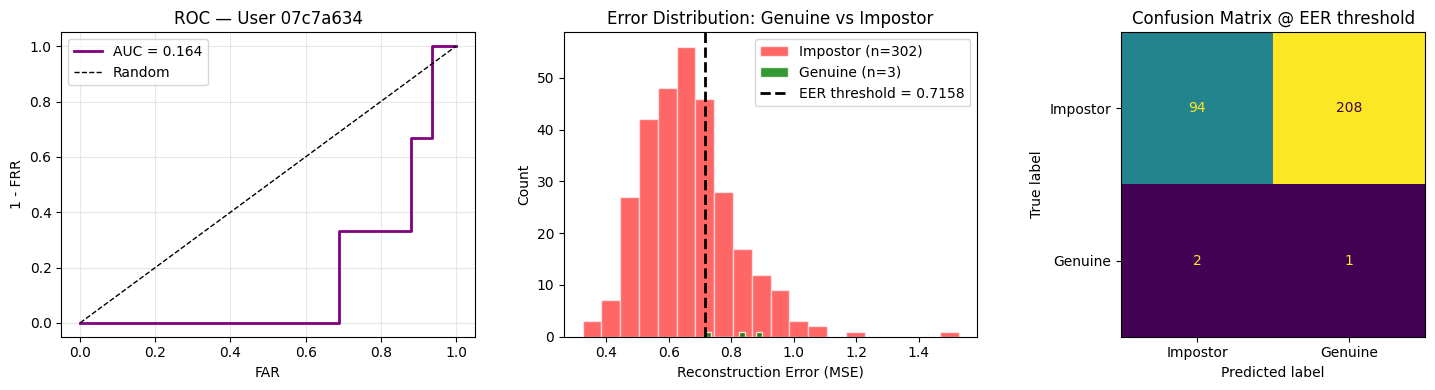

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 7: SINGLE-USER DEMO
# ─────────────────────────────────────────────────────────────────────────────

target_user = unique_users[0]
print(f'Demo evaluation — user: {target_user}\n')

result = evaluate_user(target_user, sessions_norm, labels, verbose=True)

if result:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # ROC curve
    axes[0].plot(result['fpr'], result['tpr'], color='purple', lw=2,
                 label=f'AUC = {result["auc"]:.3f}')
    axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
    axes[0].set_xlabel('FAR'); axes[0].set_ylabel('1 - FRR')
    axes[0].set_title(f'ROC — User {target_user[:8]}')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Reconstruction error distributions
    axes[1].hist(result['imp_errors'], bins=20, alpha=0.6, color='red',
                 edgecolor='white', label=f'Impostor (n={len(result["imp_errors"])})')
    axes[1].hist(result['gen_errors'], bins=10, alpha=0.8, color='green',
                 edgecolor='white', label=f'Genuine (n={len(result["gen_errors"])})')
    axes[1].axvline(result['mse_threshold'], color='black', linestyle='--', lw=2,
                    label=f'EER threshold = {result["mse_threshold"]:.4f}')
    axes[1].set_xlabel('Reconstruction Error (MSE)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Error Distribution: Genuine vs Impostor')
    axes[1].legend()

    # Confusion matrix at EER threshold
    cm = confusion_matrix(
        result['y_test'],
        (result['y_scores'] >= result['eer_thresh']).astype(int)
    )
    ConfusionMatrixDisplay(cm, display_labels=['Impostor','Genuine']).plot(
        ax=axes[2], colorbar=False
    )
    axes[2].set_title('Confusion Matrix @ EER threshold')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Keystroke_data/gru_ae_demo_user.png', dpi=150)
    plt.show()

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 8: FULL LEAVE-ONE-OUT EVALUATION (all 26 users)
# ─────────────────────────────────────────────────────────────────────────────

all_results = []

for i, user in enumerate(unique_users):
    print(f'[{i+1:02d}/{len(unique_users)}] {user[:8]}...', end=' ')
    res = evaluate_user(user, sessions_norm, labels, verbose=False)
    if res is not None:
        all_results.append(res)
        print(f'AUC={res["auc"]:.3f}  EER={res["eer"]:.3f}  '
              f'GenMSE={res["mean_gen_error"]:.4f}  ImpMSE={res["mean_imp_error"]:.4f}  '
              f'TrainWindows={res["n_train_windows"]}')
    else:
        print('SKIPPED')

print(f'\nComplete: {len(all_results)}/{len(unique_users)} users evaluated.')

[01/26] 07c7a634... AUC=0.188  EER=0.650  GenMSE=0.8075  ImpMSE=0.6740  TrainWindows=56
[02/26] 0a54ac81... AUC=0.316  EER=0.698  GenMSE=0.6916  ImpMSE=0.6173  TrainWindows=78
[03/26] 0d7d8c14... AUC=0.284  EER=0.708  GenMSE=0.7453  ImpMSE=0.6414  TrainWindows=66
[04/26] 2d472fd6... AUC=0.589  EER=0.329  GenMSE=0.5829  ImpMSE=0.6369  TrainWindows=50
[05/26] 395665da... AUC=0.604  EER=0.258  GenMSE=0.5858  ImpMSE=0.6387  TrainWindows=55
[06/26] 4269a402... AUC=0.507  EER=0.610  GenMSE=0.6105  ImpMSE=0.6326  TrainWindows=65
[07/26] 50678107... AUC=0.336  EER=0.646  GenMSE=0.7092  ImpMSE=0.6473  TrainWindows=65
[08/26] 57637896... AUC=0.496  EER=0.397  GenMSE=0.6455  ImpMSE=0.6403  TrainWindows=69
[09/26] 5f4c0735... AUC=0.795  EER=0.380  GenMSE=0.4870  ImpMSE=0.6671  TrainWindows=71
[10/26] 6a484554... AUC=0.617  EER=0.349  GenMSE=0.5514  ImpMSE=0.6248  TrainWindows=62
[11/26] 6c555496... AUC=0.173  EER=0.597  GenMSE=0.9183  ImpMSE=0.6883  TrainWindows=77
[12/26] 6ead2ae1... AUC=0.403  E

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 9: ISOLATION FOREST BASELINE (One-Class, L2 Feature Matrix)
#
# Isolation Forest is a shallow one-class anomaly detector well-suited for
# small genuine sample sizes (N=12). It requires no deep learning, no epochs,
# and trains in milliseconds. Used here as a comparison baseline to quantify
# whether the GRU Autoencoder adds value over a classical approach.
#
# Input: per-session L2 feature vectors from features.csv
#        (dwell times, digraph means, macro features — pre-extracted)
# ─────────────────────────────────────────────────────────────────────────────

if_results = []

if os.path.exists(FEATURES_PATH):
    feat_df = pd.read_csv(FEATURES_PATH)

    # ── Align with complete users ─────────────────────────────────────────
    feat_df = feat_df[feat_df['participant_id'].isin(complete_user_ids)].copy()

    # ── Fill NaN L2 features with column mean (standard for IF) ──────────
    feature_cols = [c for c in feat_df.columns
                    if c not in ['participant_id', 'session_id',
                                 'task_id', 'task_type']]
    feat_df[feature_cols] = feat_df[feature_cols].fillna(
        feat_df[feature_cols].mean()
    )

    print(f'Feature matrix: {len(feat_df)} sessions × {len(feature_cols)} features')
    print(f'Running Isolation Forest LOO across {len(unique_users)} users...\n')

    for user in unique_users:
        user_mask  = feat_df['participant_id'] == user
        X_genuine  = feat_df.loc[user_mask,  feature_cols].values
        X_impostor = feat_df.loc[~user_mask, feature_cols].values

        if len(X_genuine) < 4:
            continue

        # Train on ALL genuine sessions (IF is robust at N=12)
        clf = IsolationForest(n_estimators=100, contamination='auto',
                              random_state=42)
        clf.fit(X_genuine)

        # score_samples: more negative = more anomalous
        # Negate so higher = more genuine (consistent with GRU-AE convention)
        gen_scores = clf.score_samples(X_genuine)
        imp_scores = clf.score_samples(X_impostor)

        y_test   = np.concatenate([np.ones(len(X_genuine)),
                                   np.zeros(len(X_impostor))])
        y_scores = np.concatenate([gen_scores, imp_scores])

        try:
            auc = roc_auc_score(y_test, y_scores)
            eer, _, fpr, tpr = compute_eer(y_test, y_scores)
        except ValueError:
            auc, eer = float('nan'), float('nan')

        if_results.append(dict(user_id=user, auc=auc, eer=eer))

    if_df = pd.DataFrame(if_results)
    print(f'Isolation Forest results ({len(if_df)} users):')
    print(f'  Mean AUC : {if_df["auc"].mean():.4f}  (± {if_df["auc"].std():.4f})')
    print(f'  Mean EER : {if_df["eer"].mean():.4f}  (± {if_df["eer"].std():.4f})')
    if_df.to_csv('/content/drive/MyDrive/Keystroke_data/isolation_forest_results.csv',
                 index=False)
    print('  Saved → isolation_forest_results.csv')
else:
    print('features.csv not found. Skipping Isolation Forest baseline.')
    print(f'Expected path: {FEATURES_PATH}')
    if_df = None

Feature matrix: 313 sessions × 404 features
Running Isolation Forest LOO across 26 users...

Isolation Forest results (26 users):
  Mean AUC : 0.3051  (± 0.0651)
  Mean EER : 0.6562  (± 0.0634)
  Saved → isolation_forest_results.csv


GRU AUTOENCODER (SLIDING WINDOW) — SUMMARY RESULTS
Users evaluated      : 26
Mean AUC             : 0.4979  (± 0.2287)
Mean EER             : 0.4788  (± 0.2140)
Median EER           : 0.5017
Best EER             : 0.0000
Worst EER            : 0.9338
Mean genuine MSE     : 0.6316
Mean impostor MSE    : 0.6478
Mean train windows   : 60
Results saved → gru_ae_loo_results.csv


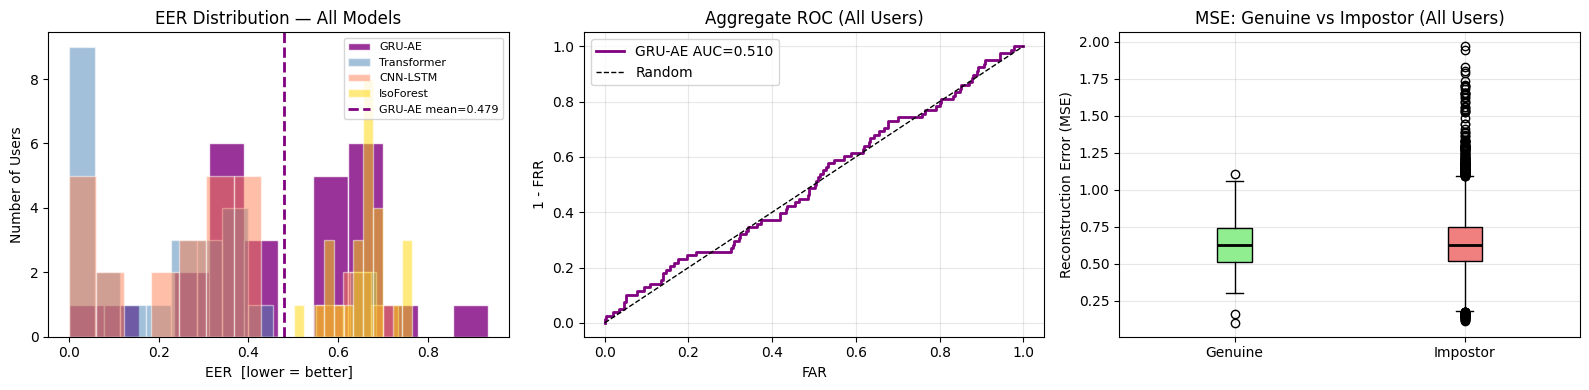


--- Full Model Comparison ---
Metric            CNN-LSTM   Transformer        GRU-AE     IsoForest
--------------------------------------------------------------------
AUC               0.7047        0.7833 ←      0.4979        0.3051  
EER               0.2968        0.2186 ←      0.4788        0.6562  


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 10: AGGREGATE RESULTS, PLOTS & FULL MODEL COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

results_df = pd.DataFrame([{
    'user_id'         : r['user_id'],
    'auc'             : r['auc'],
    'eer'             : r['eer'],
    'mse_threshold'   : r['mse_threshold'],
    'mean_gen_error'  : r['mean_gen_error'],
    'mean_imp_error'  : r['mean_imp_error'],
    'n_train_windows' : r['n_train_windows'],
} for r in all_results])

print('=' * 60)
print('GRU AUTOENCODER (SLIDING WINDOW) — SUMMARY RESULTS')
print('=' * 60)
print(f'Users evaluated      : {len(results_df)}')
print(f'Mean AUC             : {results_df["auc"].mean():.4f}  (± {results_df["auc"].std():.4f})')
print(f'Mean EER             : {results_df["eer"].mean():.4f}  (± {results_df["eer"].std():.4f})')
print(f'Median EER           : {results_df["eer"].median():.4f}')
print(f'Best EER             : {results_df["eer"].min():.4f}')
print(f'Worst EER            : {results_df["eer"].max():.4f}')
print(f'Mean genuine MSE     : {results_df["mean_gen_error"].mean():.4f}')
print(f'Mean impostor MSE    : {results_df["mean_imp_error"].mean():.4f}')
print(f'Mean train windows   : {results_df["n_train_windows"].mean():.0f}')
print('=' * 60)

results_df.to_csv(
    '/content/drive/MyDrive/Keystroke_data/gru_ae_loo_results.csv', index=False
)
print('Results saved → gru_ae_loo_results.csv')

# ── Load other model results ───────────────────────────────────────────────
cnn_path = '/content/drive/MyDrive/Keystroke_data/cnn_lstm_loo_results.csv'
tr_path  = '/content/drive/MyDrive/Keystroke_data/transformer_loo_results.csv'
cnn_df   = pd.read_csv(cnn_path) if os.path.exists(cnn_path) else None
tr_df    = pd.read_csv(tr_path)  if os.path.exists(tr_path)  else None

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: EER distributions
axes[0].hist(results_df['eer'].dropna(), bins=12, color='purple',
             edgecolor='white', alpha=0.8, label='GRU-AE')
if tr_df is not None:
    axes[0].hist(tr_df['eer'].dropna(), bins=12, color='steelblue',
                 edgecolor='white', alpha=0.5, label='Transformer')
if cnn_df is not None:
    axes[0].hist(cnn_df['eer'].dropna(), bins=12, color='coral',
                 edgecolor='white', alpha=0.5, label='CNN-LSTM')
if if_df is not None:
    axes[0].hist(if_df['eer'].dropna(), bins=12, color='gold',
                 edgecolor='white', alpha=0.5, label='IsoForest')
axes[0].axvline(results_df['eer'].mean(), color='purple', linestyle='--', lw=2,
                label=f'GRU-AE mean={results_df["eer"].mean():.3f}')
axes[0].set_xlabel('EER  [lower = better]')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('EER Distribution — All Models')
axes[0].legend(fontsize=8)

# Plot 2: Aggregate ROC
all_true   = np.concatenate([r['y_test']   for r in all_results])
all_scores = np.concatenate([r['y_scores'] for r in all_results])
agg_fpr, agg_tpr, _ = roc_curve(all_true, all_scores)
agg_auc = roc_auc_score(all_true, all_scores)
axes[1].plot(agg_fpr, agg_tpr, color='purple', lw=2,
             label=f'GRU-AE AUC={agg_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_xlabel('FAR'); axes[1].set_ylabel('1 - FRR')
axes[1].set_title('Aggregate ROC (All Users)')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Plot 3: Genuine vs Impostor MSE box plot
all_gen = np.concatenate([r['gen_errors'] for r in all_results])
all_imp = np.concatenate([r['imp_errors'] for r in all_results])
bp = axes[2].boxplot([all_gen, all_imp], labels=['Genuine','Impostor'],
                      patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[2].set_ylabel('Reconstruction Error (MSE)')
axes[2].set_title('MSE: Genuine vs Impostor (All Users)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Keystroke_data/gru_ae_summary_plots.png', dpi=150)
plt.show()

# ── Full model comparison table ───────────────────────────────────────────
print('\n--- Full Model Comparison ---')
models = {'CNN-LSTM': cnn_df, 'Transformer': tr_df,
          'GRU-AE': results_df, 'IsoForest': if_df}
available = {k: v for k, v in models.items() if v is not None}

header = f'{"Metric":<12}' + ''.join(f'{k:>14}' for k in available)
print(header)
print('-' * len(header))

for metric, better in [('auc', 'higher'), ('eer', 'lower')]:
    vals  = {k: v[metric].mean() for k, v in available.items()}
    best  = (min if better == 'lower' else max)(vals, key=vals.get)
    row   = f'{metric.upper():<12}'
    for k, v in vals.items():
        marker = ' ←' if k == best else ''
        row += f'{v:>12.4f}{marker:<2}'
    print(row)